## Load Dataset

In [27]:
import pandas as pd

data = pd.read_csv(r"C:\RainPrediction\Rain-Prediction-ML\data\weatherAUS.csv")
print(data.head())
print(data.info())

         Date Location  MinTemp  MaxTemp  Rainfall  Evaporation  Sunshine  \
0  2008-12-01   Albury     13.4     22.9       0.6          NaN       NaN   
1  2008-12-02   Albury      7.4     25.1       0.0          NaN       NaN   
2  2008-12-03   Albury     12.9     25.7       0.0          NaN       NaN   
3  2008-12-04   Albury      9.2     28.0       0.0          NaN       NaN   
4  2008-12-05   Albury     17.5     32.3       1.0          NaN       NaN   

  WindGustDir  WindGustSpeed WindDir9am  ... Humidity9am  Humidity3pm  \
0           W           44.0          W  ...        71.0         22.0   
1         WNW           44.0        NNW  ...        44.0         25.0   
2         WSW           46.0          W  ...        38.0         30.0   
3          NE           24.0         SE  ...        45.0         16.0   
4           W           41.0        ENE  ...        82.0         33.0   

   Pressure9am  Pressure3pm  Cloud9am  Cloud3pm  Temp9am  Temp3pm  RainToday  \
0       1007.7    

## Data Cleaning / Preprocessing

In [11]:
print(data.isnull().sum())

Date                 0
Location             0
MinTemp           1485
MaxTemp           1261
Rainfall          3261
Evaporation      62790
Sunshine         69835
WindGustDir      10326
WindGustSpeed    10263
WindDir9am       10566
WindDir3pm        4228
WindSpeed9am      1767
WindSpeed3pm      3062
Humidity9am       2654
Humidity3pm       4507
Pressure9am      15065
Pressure3pm      15028
Cloud9am         55888
Cloud3pm         59358
Temp9am           1767
Temp3pm           3609
RainToday         3261
RainTomorrow      3267
dtype: int64


In [7]:
data = data.drop(['Evaporation', 'Sunshine', 'Cloud9am', 'Cloud3pm'], axis=1)
data = data.dropna(subset=['RainTomorrow'])

data['RainTomorrow'] = data['RainTomorrow'].str.strip()
data['RainToday'] = data['RainToday'].str.strip()

data['RainTomorrow'] = data['RainTomorrow'].map({'Yes': 1, 'No': 0})
data['RainToday'] = data['RainToday'].map({'Yes': 1, 'No': 0})

num_cols = data.select_dtypes(include=['float64', 'int64']).columns
data[num_cols] = data[num_cols].fillna(data[num_cols].mean())

cat_cols = data.select_dtypes(include=['object', 'string']).columns
data[cat_cols] = data[cat_cols].fillna(data[cat_cols].mode().iloc[0])

print(data.isnull().sum())

Date             0
Location         0
MinTemp          0
MaxTemp          0
Rainfall         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
dtype: int64


## Exploratory Data Analysis (EDA)

### 1.Correlation Heatmap

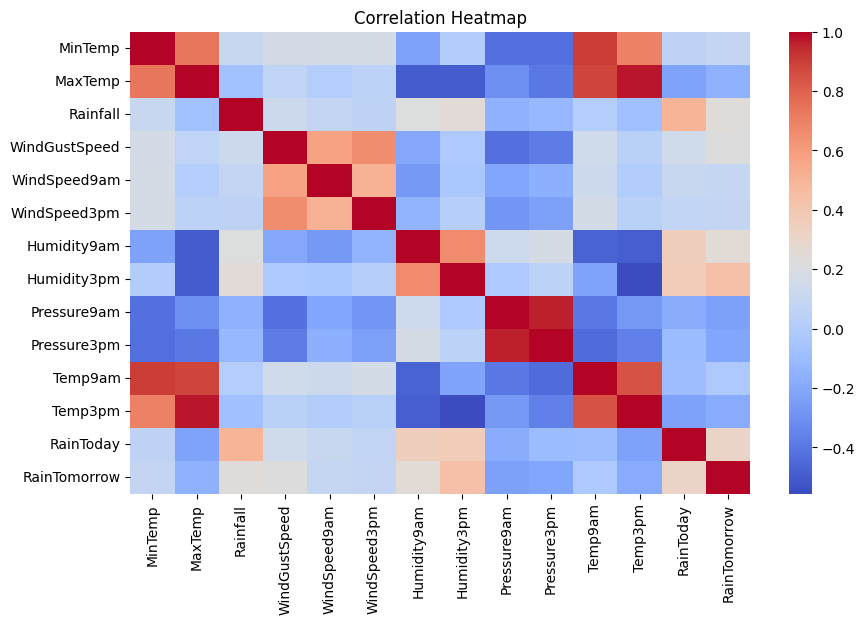

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_data = data.select_dtypes(include=['float64', 'int64'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_data.corr(), annot= False, cmap= "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### 2.Rain vs Humidity

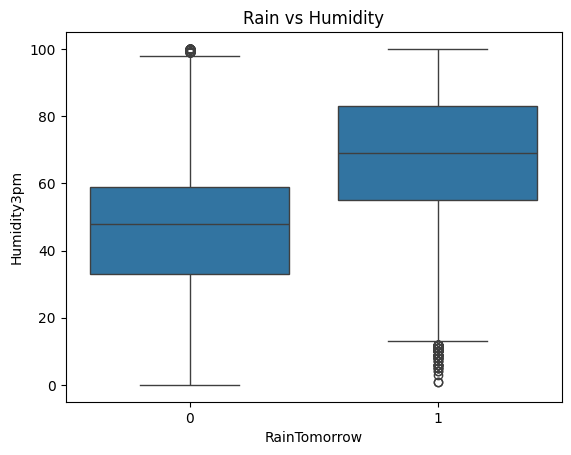

In [12]:
sns.boxplot(x = "RainTomorrow", y = "Humidity3pm", data = data)
plt.title("Rain vs Humidity")
plt.show()

### 3.Rain vs Temperature

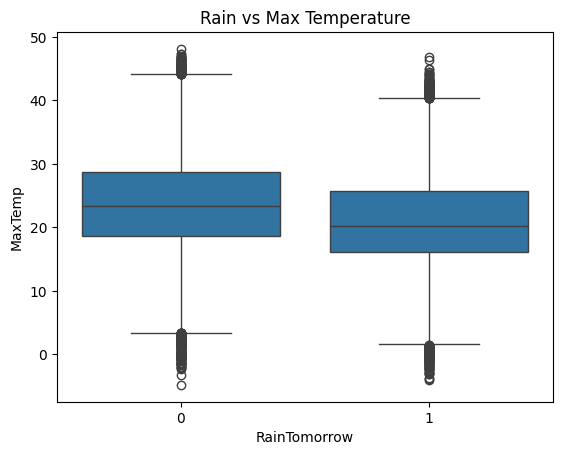

In [13]:
sns.boxplot(x = "RainTomorrow", y = "MaxTemp", data = data)
plt.title("Rain vs Max Temperature")
plt.show()

### 4.Rain Distribution

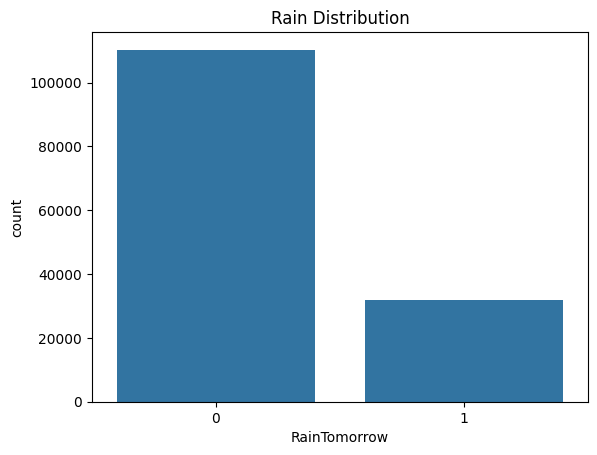

In [14]:
sns.countplot(x = "RainTomorrow", data = data)
plt.title("Rain Distribution")
plt.show()

### 5.Pairplot

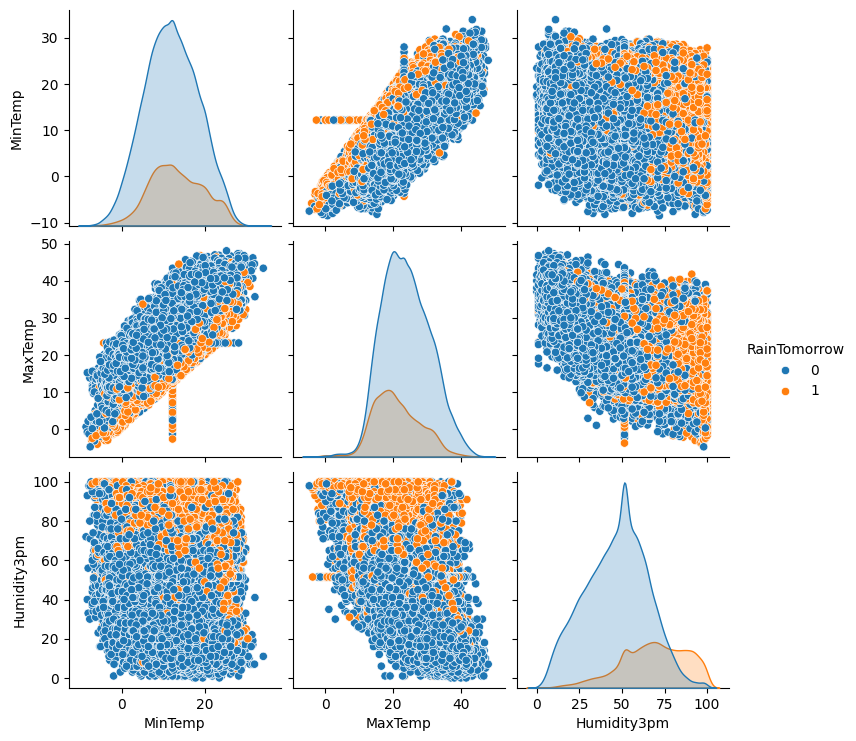

In [15]:
sns.pairplot(data[['MinTemp','MaxTemp','Humidity3pm','RainTomorrow']], hue= "RainTomorrow")
plt.show()

## Feature Selection

In [16]:
x = data[['MinTemp','MaxTemp','Humidity9am','Humidity3pm','Pressure9am','Pressure3pm','Temp9am',
          'Temp3pm','WindSpeed9am','WindSpeed3pm','RainToday']]

y = data['RainTomorrow']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, random_state= 42)

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Model Training

#### 1.Logistic Regression

In [28]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter = 2000)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Accuracy : ", accuracy)
print("confusion matrix : \n", cm)
from sklearn.metrics import classification_report
print("classification report :\n",classification_report(y_test, y_pred))

Accuracy :  0.8291430781673055
confusion matrix : 
 [[20833  1265]
 [ 3594  2747]]
classification report :
               precision    recall  f1-score   support

           0       0.85      0.94      0.90     22098
           1       0.68      0.43      0.53      6341

    accuracy                           0.83     28439
   macro avg       0.77      0.69      0.71     28439
weighted avg       0.82      0.83      0.81     28439



#### 2.K-Nearest Neighbors

In [19]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors= 5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred_knn)
cm = confusion_matrix(y_test, y_pred_knn)
print("Accuracy : ", accuracy)
print("confusion matrix : \n", cm)
print("classification report :\n",classification_report(y_test, y_pred_knn))

Accuracy :  0.8232356974577165
confusion matrix : 
 [[20546  1552]
 [ 3475  2866]]
classification report :
               precision    recall  f1-score   support

           0       0.86      0.93      0.89     22098
           1       0.65      0.45      0.53      6341

    accuracy                           0.82     28439
   macro avg       0.75      0.69      0.71     28439
weighted avg       0.81      0.82      0.81     28439



#### 3.Decision Tree

In [20]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state= 42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred_dt)
cm = confusion_matrix(y_test, y_pred_dt)
print("Accuracy : ", accuracy)
print("confusion matrix : \n", cm)
print("classification report :\n",classification_report(y_test, y_pred_dt))

Accuracy :  0.7690143816589894
confusion matrix : 
 [[18598  3500]
 [ 3069  3272]]
classification report :
               precision    recall  f1-score   support

           0       0.86      0.84      0.85     22098
           1       0.48      0.52      0.50      6341

    accuracy                           0.77     28439
   macro avg       0.67      0.68      0.67     28439
weighted avg       0.77      0.77      0.77     28439



#### 4.Random Forest Implementation

In [21]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators= 100, random_state= 42)
rf.fit(X_train,y_train)
y_pred_rf = rf.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy = accuracy_score(y_test, y_pred_rf)
cm = confusion_matrix(y_test, y_pred_rf)
print("Accuracy : ", accuracy)
print("confusion matrix : \n", cm)
print("classification report :\n",classification_report(y_test, y_pred_rf))

Accuracy :  0.8409578395864834
confusion matrix : 
 [[20908  1190]
 [ 3333  3008]]
classification report :
               precision    recall  f1-score   support

           0       0.86      0.95      0.90     22098
           1       0.72      0.47      0.57      6341

    accuracy                           0.84     28439
   macro avg       0.79      0.71      0.74     28439
weighted avg       0.83      0.84      0.83     28439



#### 5.Gaussian Naive Bayes

In [22]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_nb))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_nb))
print("Classification Report:\n", classification_report(y_test, y_pred_nb))

Accuracy: 0.7949294982242695
Confusion Matrix:
 [[18888  3210]
 [ 2622  3719]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.85      0.87     22098
           1       0.54      0.59      0.56      6341

    accuracy                           0.79     28439
   macro avg       0.71      0.72      0.71     28439
weighted avg       0.80      0.79      0.80     28439



## Handling Class Imbalance

#### 1.Balanced Logistic Regression

In [23]:
from sklearn.linear_model import LogisticRegression
model_bal = LogisticRegression(max_iter = 2000, class_weight='balanced')
model_bal.fit(X_train,y_train)
y_pred_bal = model_bal.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred_bal))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_bal))
print("Classification Report:\n", classification_report(y_test, y_pred_bal))

Accuracy: 0.7609972221245472
Confusion Matrix:
 [[16985  5113]
 [ 1684  4657]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.77      0.83     22098
           1       0.48      0.73      0.58      6341

    accuracy                           0.76     28439
   macro avg       0.69      0.75      0.71     28439
weighted avg       0.81      0.76      0.78     28439



#### 2.Balanced Random Forest Implementation

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_bal = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_bal.fit(X_train, y_train)
y_pred_rf_bal = rf_bal.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rf_bal))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf_bal))
print("Classification Report:\n", classification_report(y_test, y_pred_rf_bal))

Accuracy: 0.8408171876648265
Confusion Matrix:
 [[21090  1008]
 [ 3519  2822]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90     22098
           1       0.74      0.45      0.55      6341

    accuracy                           0.84     28439
   macro avg       0.80      0.70      0.73     28439
weighted avg       0.83      0.84      0.83     28439



## Model Comparison

| Model               | Accuracy  | Precision (Rain) | Recall (Rain) | F1-Score | FN (Missed Rain) | TP (Detected Rain) |
| ------------------- | --------- | ---------------- | ------------- | -------- | ---------------- | ------------------ |
| Logistic Regression | 82.9%     | 0.68             | 0.43          | 0.53     | 3594             | 2747               |
| KNN                 | 82.3%     | 0.65             | 0.45          | 0.53     | 3475             | 2866               |
| Decision Tree       | 76.9%     | 0.48             | 0.52          | 0.50     | 3069             | 3272               |
| Random Forest       | **84.1%** | **0.72**         | 0.47          | **0.57** | 3333             | 3008               |
| Naive Bayes         | 79.5%     | 0.54             | **0.59**      | 0.56     | **2622**         | **3719**           |


| Model                          | Accuracy | Precision (Rain) | Recall (Rain) | F1-Score | FN (Missed Rain) | TP (Detected Rain) |
| ------------------------------ | -------- | ---------------- | ------------- | -------- | ---------------- | ------------------ |
| Logistic Regression (Balanced) | 76.1%    | 0.48             | **0.73**      | **0.58** | **1684**         | **4657**           |
| Random Forest (Balanced)       | 84.0%    | 0.74             | 0.45          | 0.55     | 3519             | 2822               |


## Principal Component Analysis (PCA)

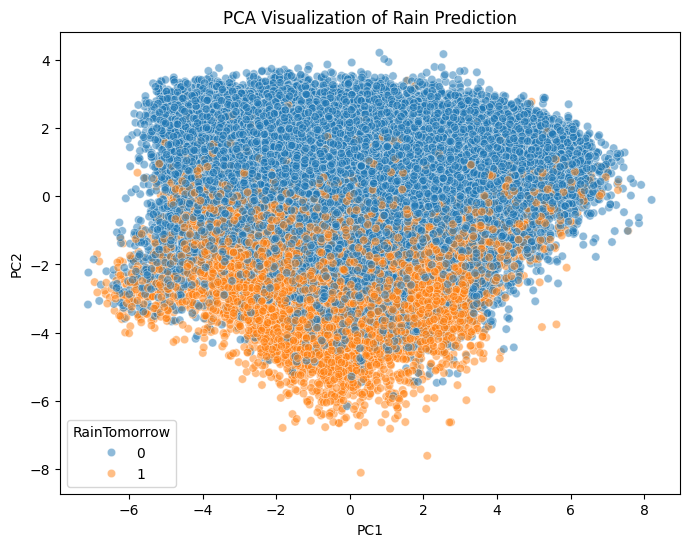

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

import pandas as pd
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['RainTomorrow'] = y.values

import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='RainTomorrow', data=pca_df, alpha=0.5)
plt.title("PCA Visualization of Rain Prediction")
plt.show()

## K-Means Clustering

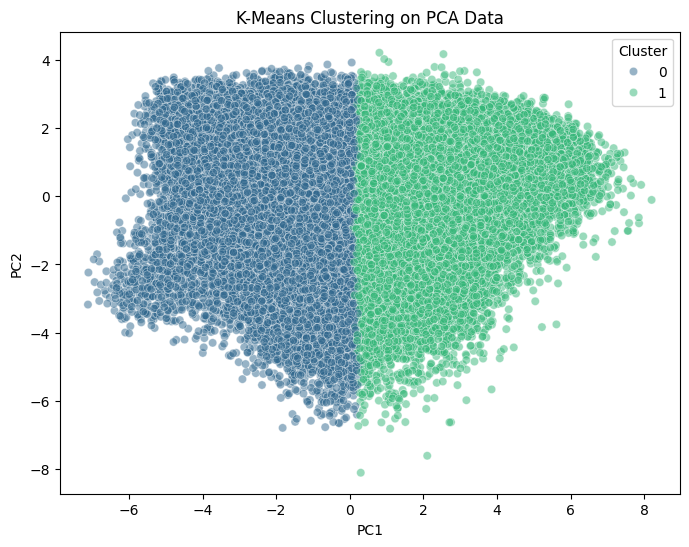

In [26]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

pca_df['Cluster'] = clusters
plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_df, palette='viridis', alpha=0.5)
plt.title("K-Means Clustering on PCA Data")
plt.show()

## Conclusion
Random Forest performed best overall, while Logistic Regression (balanced) gave better recall for rain prediction.